# RegionMask

The RegionMask object is the geospatial representation of the given region, allows to combine raster and vector operations and many functions. 

**Import required packages**

GeoKit is imported to provide the required functionality for working with vector data.


In [1]:
import geokit as gk
import numpy as np
import pandas as pd
import pathlib
from geokit.core.get_test_data import get_test_data

**Load Region Mask**

In [24]:
# load the region mask from the passed shape file
import pathlib
from geokit.core.get_test_data import get_test_data

# Define the srs
aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)

# Path to cache folder
data_cache_folder = pathlib.Path().cwd().parent.parent.joinpath("geokit", "data")

# Load Region Mask
aachen_rm = gk.RegionMask.load(
    get_test_data(
        file_name="aachenShapefile.shp",
        data_cache_folder=data_cache_folder,
    ),
    pixelRes=20,
    srs=aachen_centered_srs,
)

# print basic info
print("aachen_rm.extent", aachen_rm.extent)
# print("aachen_rm.srs", aachen_rm.srs)
print("aachen_rm.pixelWidth", aachen_rm.pixelWidth)
print("aachen_rm.pixelHeight", aachen_rm.pixelHeight)

aachen_rm.extent (-7640.00000,-31220.00000,23820.00000,19500.00000)
aachen_rm.pixelWidth 20
aachen_rm.pixelHeight 20


## Region Mask and Raster-File

A RegionMask object allows raster data to be warped onto the RegionMask's characteristics (as in the RegionMask's resolution, extent, and spatial reference system). This create a numpy matrix, from which only the pixels which lie in the region can be easily extracted and operated on.


Example: Extract the GHI-data for Aachen from a raster-file for the GHI in Germany.


AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f4dc519e350>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f4dc519e490>)

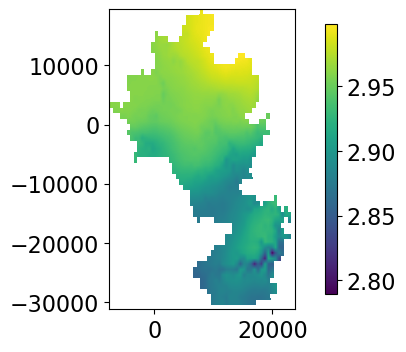

In [25]:
ras = aachen_rm.warp(
    get_test_data(file_name="gsa-ghi-like.tif", data_cache_folder=data_cache_folder),
    returnMatrix=False,
)
gk.drawRaster(ras, figsize=(3, 3))